In [1]:
import sys
sys.path.append('../simulation')
from chi_computation import compute_chi
from filter_functions import F_Hahn, F_CPMG
from noise_models import total_noise
from inversion import alvarez_suter, tikhonov

import numpy as np
import matplotlib.pyplot as plt


In [2]:
omega = np.linspace(0, 10e6, 10000)
A_pink = 1e9
alpha = 1.0
A_white = 1e3
A_lorentzian = 5e5
f0 = 5e6
gamma = 5e4

c:\Users\omaru\Projects\qubit-noise-spectroscopy\notebooks\../simulation\noise_models.py:4: RuntimeWarning: divide by zero encountered in divide
  return np.where(f == 0, 0, A / f**alpha)


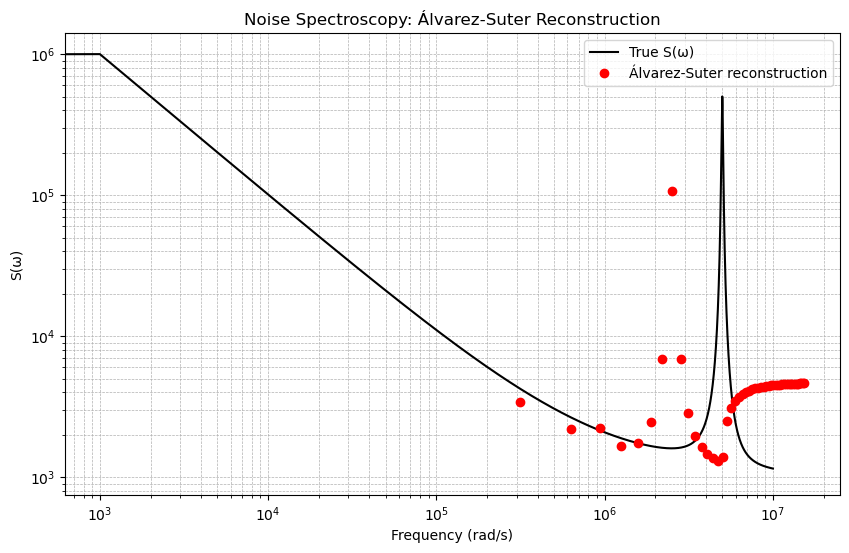

In [3]:
n_list = np.arange(1, 50)
t_fixed = 10e-6

omega_probe, S_reconstructed = alvarez_suter(t_fixed, n_list, omega,
    total_noise(omega, A_pink, alpha, A_white, A_lorentzian, f0, gamma))

plt.figure(figsize=(10, 6))
plt.plot(omega, total_noise(omega, A_pink, alpha, A_white, A_lorentzian, f0, gamma), 
         label='True S(ω)', color='black')
plt.plot(omega_probe, S_reconstructed, 'o', label='Álvarez-Suter reconstruction', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('S(ω)')
plt.title('Noise Spectroscopy: Álvarez-Suter Reconstruction')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

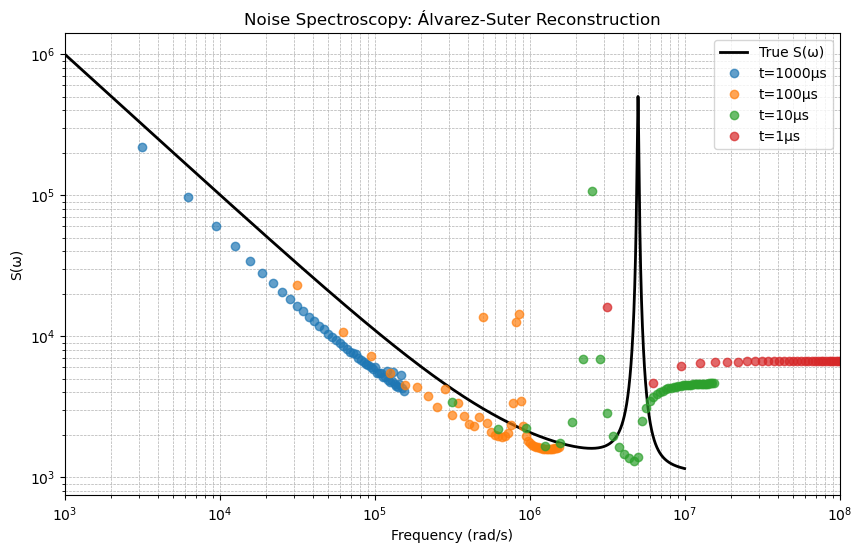

In [4]:
t_values = [1000e-6, 100e-6, 10e-6, 1e-6]
n_list = np.arange(1, 50)

plt.figure(figsize=(10, 6))
plt.plot(omega, total_noise(omega, A_pink, alpha, A_white, A_lorentzian, f0, gamma), 
         label='True S(ω)', color='black', linewidth=2)

for t_fixed in t_values:
    omega_probe, S_reconstructed = alvarez_suter(t_fixed, n_list, omega,
        total_noise(omega, A_pink, alpha, A_white, A_lorentzian, f0, gamma))
    plt.plot(omega_probe, S_reconstructed, 'o', label=f't={t_fixed*1e6:.0f}µs', alpha=0.7)

plt.xlim(1e3, 1e8)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('S(ω)')
plt.title('Noise Spectroscopy: Álvarez-Suter Reconstruction')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

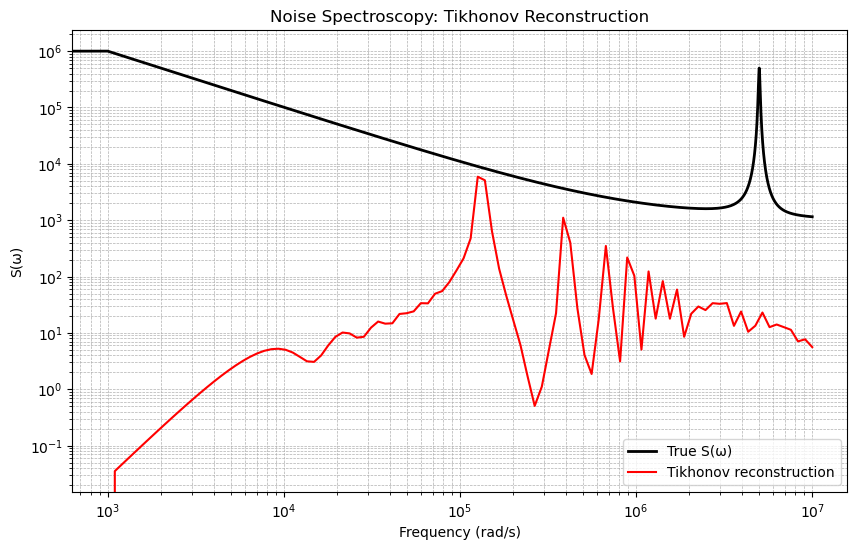

In [7]:
t_list = np.linspace(1e-6, 500e-6, 100)
omega_recon = np.logspace(3, 7, 100)
chi_list = []
for t in t_list:
    F_vals = F_Hahn(omega, t)
    chi = compute_chi(omega, total_noise(omega, A_pink, alpha, A_white, A_lorentzian, f0, gamma), F_vals)
    chi_list.append(chi)

omega_recon, S_tik = tikhonov(t_list, chi_list, omega_recon, lambda_reg=1e-5)

plt.figure(figsize=(10, 6))
plt.plot(omega, total_noise(omega, A_pink, alpha, A_white, A_lorentzian, f0, gamma), 
         label='True S(ω)', color='black', linewidth=2)
plt.plot(omega_recon, S_tik, label='Tikhonov reconstruction', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('S(ω)')
plt.title('Noise Spectroscopy: Tikhonov Reconstruction')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()